# WEEK 4 - EDA Deep Dive

## Univariate and Bivariate Analysis

In this week, Exploratory Data Analysis (EDA) is performed on the cleaned
dataset to understand distributions, patterns and relationships between
different attributes.

The analysis includes:

- Univariate Analysis
- Distribution Analysis
- Bivariate Analysis
- Visualization of important relationships
- Interpretation of key findings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## Loading the Cleaned Dataset

The cleaned dataset generated during Week 3 is used for Exploratory
Data Analysis.

In [2]:
df = pd.read_csv("Dataset/cleaned_social_media_data.csv")

print("Cleaned dataset loaded successfully!")
print("Dataset shape:", df.shape)

Cleaned dataset loaded successfully!
Dataset shape: (30000, 19)


In [3]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


## Univariate Analysis

### Distribution of Daily Social Media Time

A histogram with a KDE curve is used to understand how daily social
media usage is distributed among users.

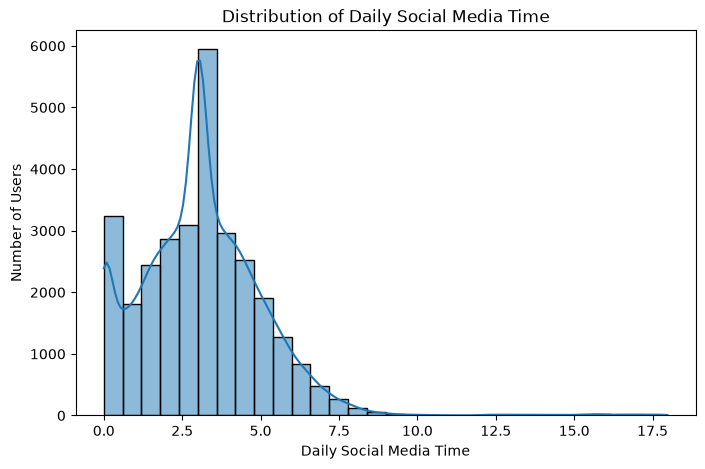

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="daily_social_media_time",
    bins=30,
    kde=True
)

plt.title("Distribution of Daily Social Media Time")
plt.xlabel("Daily Social Media Time")
plt.ylabel("Number of Users")

plt.show()

### Observation

The distribution of daily social media time is positively skewed.

Most users spend a moderate amount of time on social media, while a
smaller group of users shows very high usage.

These high-usage users may represent excessive social media behaviour.

### Preferred Social Media Platform

A count plot is used to compare the number of users preferring each
social media platform.

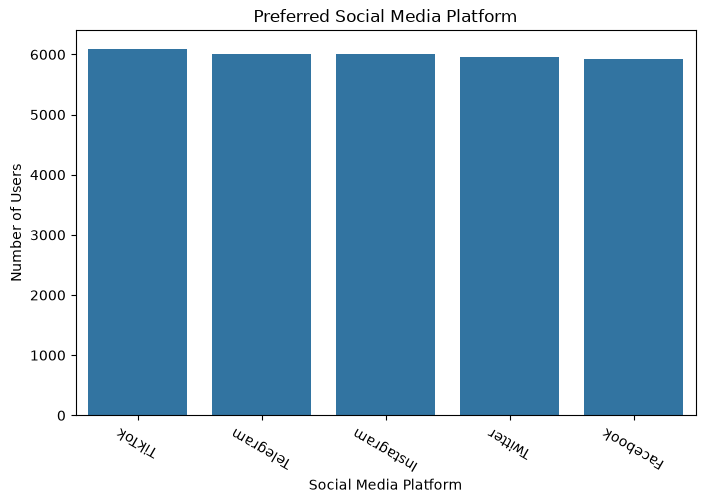

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="social_platform_preference",
    order=df["social_platform_preference"].value_counts().index
)

plt.title("Preferred Social Media Platform")
plt.xlabel("Social Media Platform")
plt.ylabel("Number of Users")
plt.xticks(rotation=150)

plt.show()

### Observation

The count plot shows how users are distributed across different social
media platforms.

Some platforms are preferred by more users than others, indicating
differences in platform popularity within the dataset.

### Actual Productivity Score

A box plot is used to study the central tendency, spread and possible
extreme values in actual productivity scores.

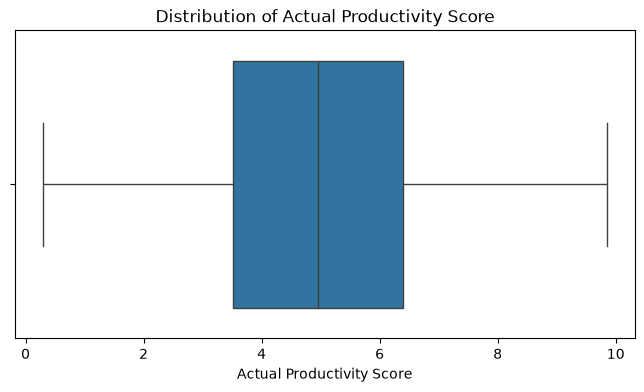

In [12]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=df,
    x="actual_productivity_score"
)

plt.title("Distribution of Actual Productivity Score")
plt.xlabel("Actual Productivity Score")

plt.show()

### Observation

The box plot shows the spread and central range of productivity scores.

It also helps identify whether unusually low or high productivity
scores are present in the dataset.

### Distribution of Sleep Hours

A violin plot is used to visualize both the distribution and density
of users' sleep duration.

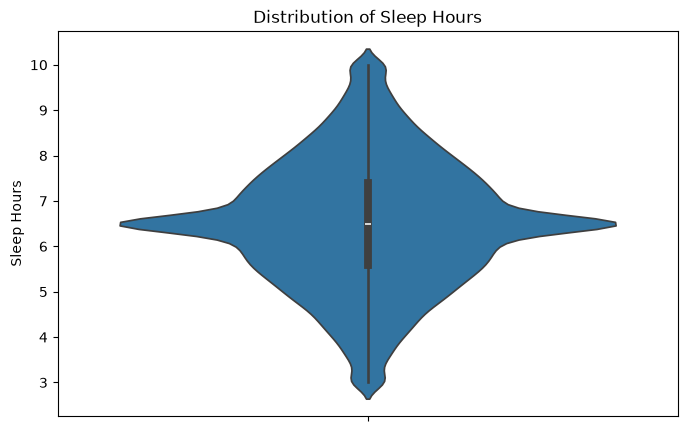

In [13]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    y="sleep_hours"
)

plt.title("Distribution of Sleep Hours")
plt.ylabel("Sleep Hours")

plt.show()

### Observation

The violin plot shows the concentration and spread of sleep duration.

The wider regions represent sleep ranges where a larger number of
users are concentrated.

### Gender Distribution

A count plot is used to visualize the number of users belonging to
each gender category in the dataset.

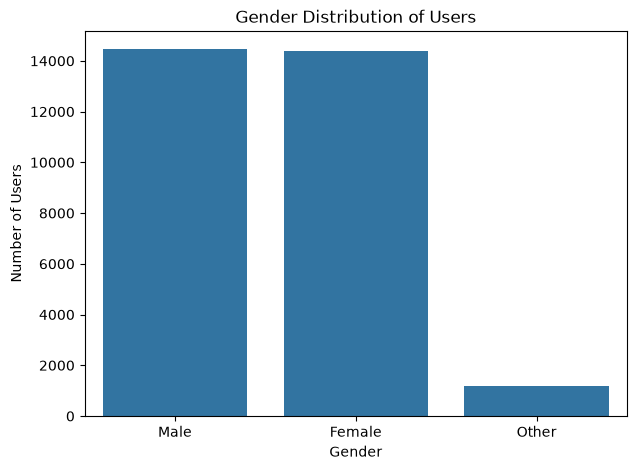

In [14]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="gender",
    order=df["gender"].value_counts().index
)

plt.title("Gender Distribution of Users")
plt.xlabel("Gender")
plt.ylabel("Number of Users")

plt.show()

### Observation

The count plot shows the distribution of users across different gender
categories and helps identify whether the dataset is balanced or dominated
by any particular group.

## Bivariate Analysis

### Daily Social Media Time vs Actual Productivity

A scatter plot with a regression line is used to study the relationship
between daily social media usage and actual productivity.

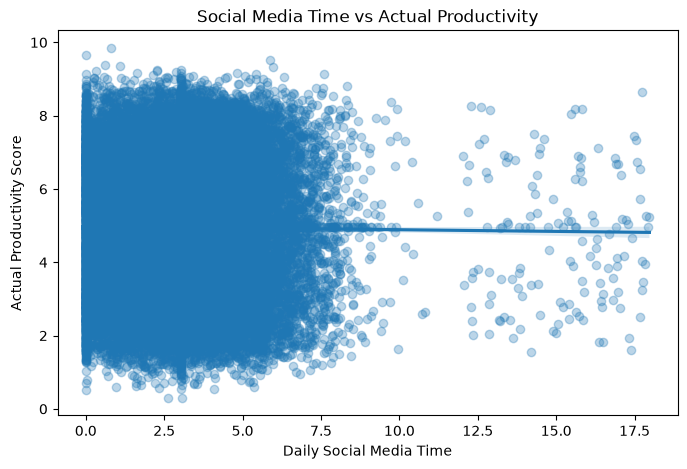

In [15]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="daily_social_media_time",
    y="actual_productivity_score",
    scatter_kws={"alpha":0.3}
)

plt.title("Social Media Time vs Actual Productivity")
plt.xlabel("Daily Social Media Time")
plt.ylabel("Actual Productivity Score")

plt.show()

### Observation

The scatter plot shows how actual productivity changes with daily
social media usage.

The regression line helps identify whether the relationship between
social media time and productivity is positive, negative or weak.

### Daily Social Media Time vs Stress Level

A box plot is used to compare daily social media usage across different
stress levels.

This helps identify whether users with higher stress levels tend to show
different social media usage patterns.

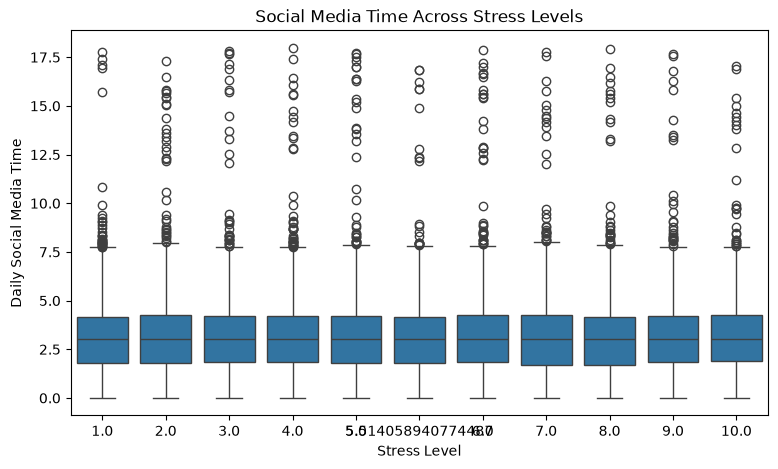

In [16]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="stress_level",
    y="daily_social_media_time"
)

plt.title("Social Media Time Across Stress Levels")
plt.xlabel("Stress Level")
plt.ylabel("Daily Social Media Time")

plt.show()

### Observation

The box plot compares the distribution of daily social media usage across
different stress levels.

Differences in the median and spread of the boxes can indicate whether
social media usage varies as stress level changes.

### Daily Social Media Time vs Sleep Hours

A hexbin plot is used to study the relationship between daily social
media usage and sleep duration.

The denser regions represent combinations where a larger number of users
are concentrated.

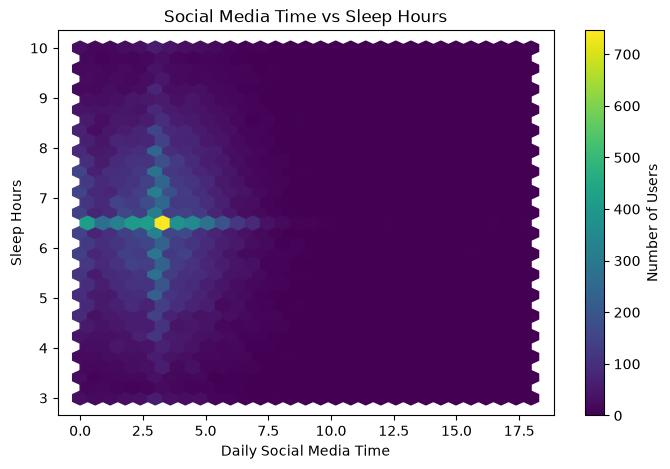

In [18]:
plt.figure(figsize=(8,5))

plt.hexbin(
    df["daily_social_media_time"],
    df["sleep_hours"],
    gridsize=30,
    cmap="viridis"
)

plt.colorbar(label="Number of Users")

plt.title("Social Media Time vs Sleep Hours")
plt.xlabel("Daily Social Media Time")
plt.ylabel("Sleep Hours")

plt.show()

### Social Media Platform Preference vs Actual Productivity

A violin plot is used to compare the distribution of actual productivity
scores across different preferred social media platforms.

This helps identify whether productivity patterns vary between platform
preference groups.

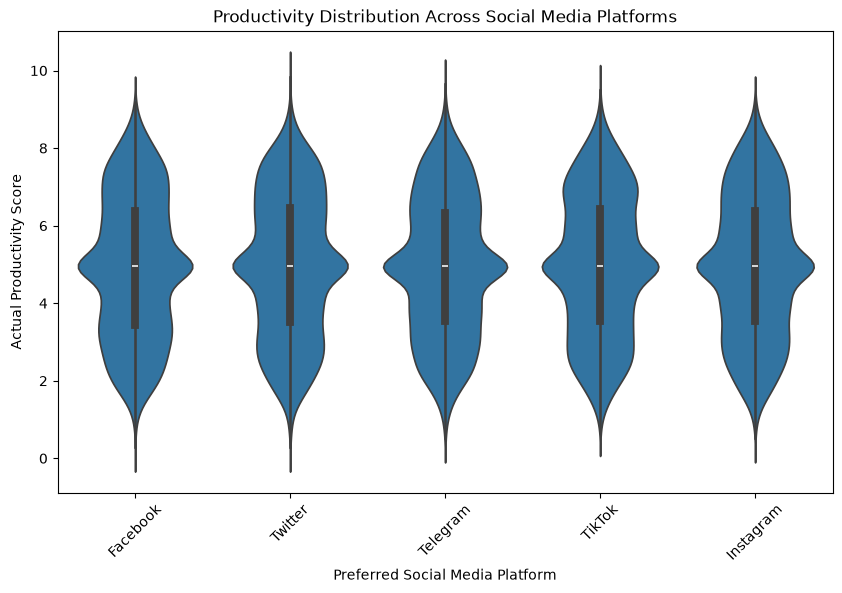

In [19]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x="social_platform_preference",
    y="actual_productivity_score"
)

plt.title("Productivity Distribution Across Social Media Platforms")
plt.xlabel("Preferred Social Media Platform")
plt.ylabel("Actual Productivity Score")
plt.xticks(rotation=45)

plt.show()

### Observation

The violin plot compares the productivity score distribution across
different social media platform preferences.

The width of each violin shows where more users are concentrated, while
differences in the distributions may indicate variation in productivity
patterns across platforms.

### Job Satisfaction vs Actual Productivity

A scatter plot is used to study the relationship between job satisfaction
and actual productivity.

This helps examine whether users with different levels of job satisfaction
show different productivity patterns.

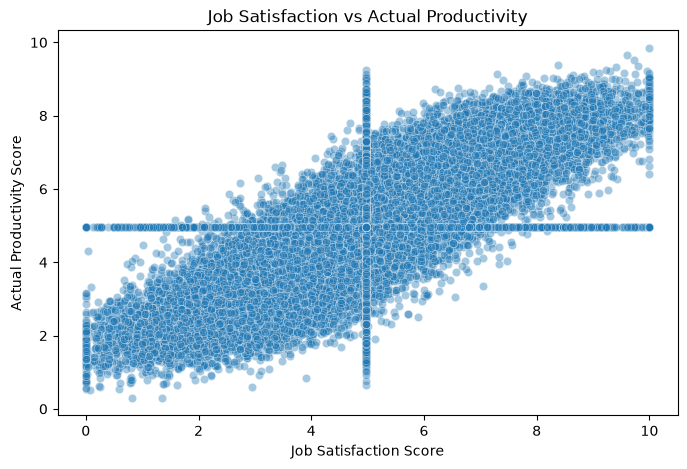

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="job_satisfaction_score",
    y="actual_productivity_score",
    alpha=0.4
)

plt.title("Job Satisfaction vs Actual Productivity")
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Actual Productivity Score")

plt.show()

### Observation

The scatter plot shows how actual productivity scores are distributed
across different job satisfaction levels.

The overall pattern can be used to identify whether a noticeable
relationship exists between job satisfaction and productivity.

## Correlation Heatmap

A correlation heatmap is used to understand the strength and direction
of relationships between numerical attributes in the dataset.

Correlation values range from -1 to +1:

- Values close to +1 indicate a strong positive relationship.
- Values close to -1 indicate a strong negative relationship.
- Values close to 0 indicate a weak or no linear relationship.

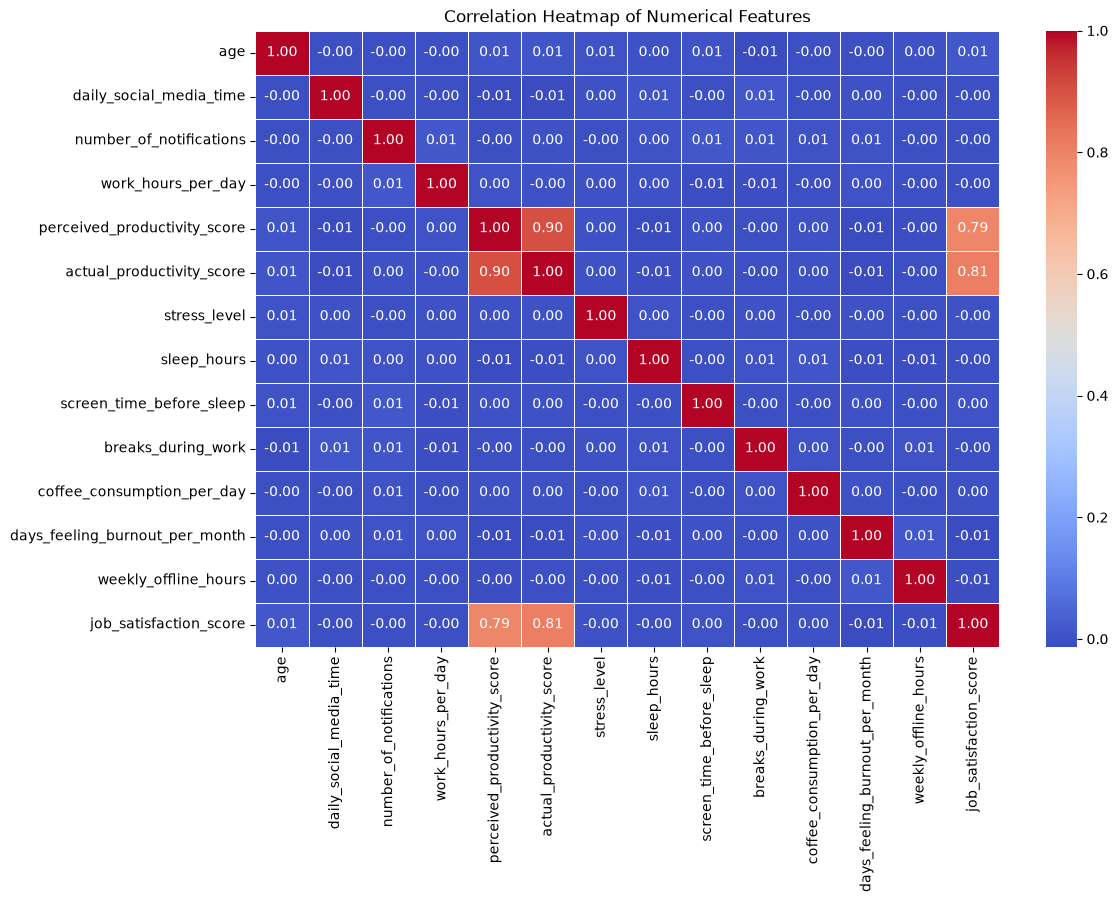

In [21]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

### Observation

The correlation heatmap provides an overall view of relationships among
the numerical attributes.

It helps identify which variables are positively related, negatively
related or only weakly related to each other.

The strongest and most relevant relationships can be selected for further
interpretation in the mid-review presentation.

## Key Findings from Correlation Analysis

The strongest numerical relationships are extracted from the correlation
matrix to identify the most meaningful patterns in the dataset.

In [22]:
corr_pairs = correlation_matrix.unstack()

corr_pairs = corr_pairs[
    corr_pairs.index.get_level_values(0) !=
    corr_pairs.index.get_level_values(1)
]

top_correlations = (
    corr_pairs.abs()
    .sort_values(ascending=False)
    .drop_duplicates()
    .head(6)
)

top_correlations

actual_productivity_score     perceived_productivity_score      0.901342
job_satisfaction_score        actual_productivity_score         0.809291
perceived_productivity_score  job_satisfaction_score            0.791146
weekly_offline_hours          days_feeling_burnout_per_month    0.014774
daily_social_media_time       breaks_during_work                0.014209
job_satisfaction_score        age                               0.013443
dtype: float64

## Week 4 Key Findings

- Daily social media usage shows a positively skewed distribution, indicating
  that most users have moderate usage while a smaller group shows high usage.

- Users are distributed across multiple social media platforms, with no single
  platform overwhelmingly dominating the dataset.

- Perceived productivity and actual productivity show a strong positive
  relationship.

- Job satisfaction shows a strong positive relationship with actual productivity.

- Daily social media time shows only a very weak linear relationship with
  actual productivity, sleep hours and stress level.

- This suggests that productivity and digital well-being may depend on multiple
  factors rather than social media usage alone.

- Univariate and bivariate visualizations helped identify distributions,
  patterns and relationships within the cleaned dataset.